# Lecture 8 - Visualisation

## Would you survive the Titanic?

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import random
import numpy as np
import pandas as pd

#Path for saving imgs
img_path="img/visu/"

#### Using basic python + scipy

In [2]:
titanic_csv = 'data/titanic3.csv'
SEP='\t'
titanic_data = open( titanic_csv, 'r' ).readlines()
print( '#Lines:', len( titanic_data ))

cats = titanic_data[0].strip().split(SEP)
print( 'Categories:', ', '.join( cats ) ) 

passengers = []
for p in titanic_data[1:]:
    pdict = {}
    for i,v in enumerate( p.strip().split(SEP) ):
        try:
            pdict[cats[i]] = float(v)
        except:
            pdict[cats[i]] = v
    passengers.append( pdict )
    
print( "#Passengers:", len(passengers) )

#Lines: 1310
Categories: pclass, survived, name, sex, age, sibsp, parch, ticket, fare, cabin, embarked, boat, body, home.dest
#Passengers: 1309


In [3]:
print( '\n#Passengers:', len(passengers ))
print( '#Survivors:', len( [p for p in passengers if p['survived']==1] ))
mean_surviv = len( [p for p in passengers if p['survived']==1] ) / len(passengers )
print( 'Mean of survivance:', mean_surviv )
print( '%Survivors:', round( mean_surviv*100, 2), '%' )
print()


#Passengers: 1309
#Survivors: 500
Mean of survivance: 0.3819709702062643
%Survivors: 38.2 %



In [4]:
import numpy as np

# Print the chance of survival depending on the class
classes = np.unique( [int(p['pclass']) for p in passengers] )
print( 'Stats per class', classes)
for c in classes:
    mean_surviv = len( [p for p in passengers if p['survived']==1 and p['pclass']==c] ) / len( [p for p in passengers if p['pclass']==c] )
    #print( '#Unk age:', len( [p['age'] for p in passengers if p['pclass']==c and p['age']=='']) )
    mean_age = np.mean( [p['age'] for p in passengers if p['pclass']==c and p['age']!=''] )
    print('Class -', c, ': %Survivors:', round( mean_surviv*100, 2 ), '%', '; Mean age',   round( mean_age, 1 ) )

Stats per class [1 2 3]
Class - 1 : %Survivors: 61.92 % ; Mean age 39.2
Class - 2 : %Survivors: 42.96 % ; Mean age 29.5
Class - 3 : %Survivors: 25.53 % ; Mean age 24.8


In [5]:
from scipy import stats
# stats
print( 'For all:', stats.describe([p['age'] for p in passengers if p['age']!='']) )

print( 'for 1st class:', stats.describe([p['age'] for p in passengers if p['age']!='' and p['pclass']==1]) )


For all: DescribeResult(nobs=1046, minmax=(np.float64(0.1667), np.float64(80.0)), mean=np.float64(29.8811345124283), variance=np.float64(207.7489735996977), skewness=np.float64(0.4070870379484177), kurtosis=np.float64(0.14051780299368888))
for 1st class: DescribeResult(nobs=284, minmax=(np.float64(0.9167), np.float64(80.0)), mean=np.float64(39.15991795774648), variance=np.float64(211.64602400345728), skewness=np.float64(0.05401535325894106), kurtosis=np.float64(-0.4604178068089704))


In [188]:
from scipy import stats
import numpy as np
import statistics

# How much passengers paid on an average?
print( "Mean fare:", np.mean( [p['fare'] for p in passengers if p['fare']!=''] ) )
print( "Median fare:", np.median( [p['fare'] for p in passengers if p['fare']!=''] ))
print( "Mode fare:", stats.mode( [p['fare'] for p in passengers if p['fare']!=''] ) )
print( "Range fare:", np.min([p['fare'] for p in passengers if p['fare']!=''] ), np.max([p['fare'] for p in passengers if p['fare']!=''] ) )
print( stats.describe([p['fare'] for p in passengers if p['fare']!='']))
print()
# How old are passengers?
print( "Mean age:", np.mean( [p['age'] for p in passengers if p['age']!=''] ) )
print( "Median age:", np.median( [p['age'] for p in passengers if p['age']!=''] ) )
print( "Mode age:", stats.mode( [p['age'] for p in passengers if p['age']!=''] ) )
print( "Range age:", np.min([p['age'] for p in passengers if p['age']!=''] ), np.max([p['age'] for p in passengers if p['age']!=''] ) )
print( stats.describe([p['age'] for p in passengers if p['age']!='']))
print()

# mode() is not only for real values, also for categorical values
print( "Mode sex:", statistics.mode( [p['sex'] for p in passengers if p['sex']!=''] ) )
print( "Mode sex:", stats.mode( [p['sex'] for p in passengers if p['sex']!=''] ))
print( "Mode age:", stats.mode( [p['age'] for p in passengers if p['age']!=''] ) )

Mean fare: 33.29547928134557
Median fare: 14.4542
Mode fare: ModeResult(mode=array([8.05]), count=array([60]))
Range fare: 0.0 512.3292
DescribeResult(nobs=1308, minmax=(0.0, 512.3292), mean=33.29547928134557, variance=2678.959737892891, skewness=4.362698696939623, kurtosis=26.9201952318479)

Mean age: 29.8811345124283
Median age: 28.0
Mode age: ModeResult(mode=array([24.]), count=array([47]))
Range age: 0.1667 80.0
DescribeResult(nobs=1046, minmax=(0.1667, 80.0), mean=29.8811345124283, variance=207.7489735996977, skewness=0.4070870379484177, kurtosis=0.14051780299368888)

Mode sex: male
Mode sex: ModeResult(mode=array(['male'], dtype='<U6'), count=array([843]))
Mode age: ModeResult(mode=array([24.]), count=array([47]))


/home/chloe/anaconda3/lib/python3.6/site-packages/scipy/stats/stats.py:245: RuntimeWarning: The input array could not be properly checked for nan values. nan values will be ignored.
  "values. nan values will be ignored.", RuntimeWarning)


In [189]:
titanic_csv = 'data/titanic3.csv'
SEP='\t'
titanic_data = open( titanic_csv, 'r' ).readlines()
print( '# lines', len( titanic_data ))

cats = titanic_data[0].strip().split(SEP)
print( 'Categories:', ', '.join( cats ) ) 

passengers = []
for p in titanic_data[1:]:
    pdict = {}
    for i,v in enumerate( p.strip().split(SEP) ):
        try:
            pdict[cats[i]] = float(v)
        except:
            pdict[cats[i]] = v
    passengers.append( pdict )
    
def pprint_perc( n ):
    return round( n*100, 2 )

#passengers = [ {c:v for c in cats for p in titanic_data[1:] for v in p.strip().split(',')} ]
print( '\n#Passengers:', len(passengers ))
print( '#Survivors:', len( [p for p in passengers if p['survived']==1] ))
print( 'Mean of survivance:', len( [p for p in passengers if p['survived']==1] ) / len(passengers ) )
print( '%Survivors:', pprint_perc( len( [p for p in passengers if p['survived']==1] ) / len(passengers ) ), '%' )
print()

# Print the chance of survival depending on the class
print( 'Stats per class')
classes = np.unique( [p['pclass'] for p in passengers] )
#print( 'Classes:', classes)
for c in classes:
    print( '\n- Class:', c)
    print('%Survivors:', pprint_perc( len( [p for p in passengers if p['survived']==1 and p['pclass']==c] ) / len( [p for p in passengers if p['pclass']==c] ) ), '%' )
    print( '#Unk age:', len( [p['age'] for p in passengers if p['pclass']==c and p['age']=='']) )
    print( 'Mean age', np.mean( [p['age'] for p in passengers if p['pclass']==c and p['age']!=''] ) )
    print( '#Children', len( [p['age'] for p in passengers if p['pclass']==c and p['age']!='' and p['age']<18]) )
    print( '#Children survivors', len( [p['age'] for p in passengers if p['pclass']==c and p['age']!='' and p['age']<18 and p['survived']==1]) )

# lines 1310
Categories: pclass, survived, name, sex, age, sibsp, parch, ticket, fare, cabin, embarked, boat, body, home.dest

#Passengers: 1309
#Survivors: 500
Mean of survivance: 0.3819709702062643
%Survivors: 38.2 %

Stats per class

- Class: 1.0
%Survivors: 61.92 %
#Unk age: 39
Mean age 39.15991795774648
#Children 15
#Children survivors 13

- Class: 2.0
%Survivors: 42.96 %
#Unk age: 16
Mean age 29.506704980842912
#Children 33
#Children survivors 29

- Class: 3.0
%Survivors: 25.53 %
#Unk age: 208
Mean age 24.81636726546906
#Children 106
#Children survivors 39


#### Using panda

In [191]:
# Source: https://github.com/andrewblane/DataFrame_to_image
# Save a panda table into a png file
import imgkit, os

# modified from http://cssmenumaker.com/br/blog/stylish-css-tables-tutorial
css = """
<style type=\"text/css\">
table {
color: #333;
font-family: Helvetica, Arial, sans-serif;
width: 640px;
border-collapse:
collapse; 
border-spacing: 0;
}
td, th {
border: 1px solid transparent; /* No more visible border */
height: 30px;
}
th {
background: #DFDFDF; /* Darken header a bit */
font-weight: bold;
}
td {
background: #FAFAFA;
text-align: center;
}
table tr:nth-child(odd) td{
background-color: white;
}
</style>
"""
def DataFrame_to_image(data, css, outputfile="out.png", format="png"):
    '''
    For rendering a Pandas DataFrame as an image.
    data: a pandas DataFrame
    css: a string containing rules for styling the output table. This must 
         contain both the opening an closing <style> tags.
    *outputimage: filename for saving of generated image
    *format: output format, as supported by IMGKit. Default is "png"
    '''
    fn = str(random.random()*100000000).split(".")[0] + ".html"
    
    try:
        os.remove(fn)
    except:
        None
    text_file = open(fn, "a")
    
    # write the CSS
    text_file.write(css)
    # write the HTML-ized Pandas DataFrame
    text_file.write(data.to_html())
    text_file.close()
    
    # See IMGKit options for full configuration,
    # e.g. cropping of final image
    imgkitoptions = {"format": format}
    
    imgkit.from_file(fn, outputfile, options=imgkitoptions)
    os.remove(fn)

In [192]:
titanic_df = pd.read_excel('data/titanic3.xls', 'titanic3', index_col=None, na_values=['NA'])
tit_head = titanic_df.head()
titanic_df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [193]:
print( "Mean survivors:", titanic_df['survived'].mean() )
print( "Age describe:" )
titanic_df['age'].describe()

Mean survivors: 0.3819709702062643
Age describe:


count    1046.000000
mean       29.881135
std        14.413500
min         0.166700
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

In [194]:
titanic_df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [195]:
tit_class = titanic_df.groupby('pclass').mean()
titanic_df.groupby('pclass').mean()

,survived,age,sibsp,parch,fare,body
pclass,,,,,,
1,0.619195,39.159918,0.436533,0.365325,87.508992,162.828571
2,0.429603,29.506705,0.393502,0.368231,21.179196,167.387097
3,0.255289,24.816367,0.568406,0.400564,13.302889,155.818182


In [196]:
titanic_df.groupby('sex').mean()

,pclass,survived,age,sibsp,parch,fare,body
sex,,,,,,,
female,2.154506,0.727468,28.687071,0.652361,0.633047,46.198097,166.62500
male,2.372479,0.190985,30.585233,0.413998,0.247924,26.154601,160.39823


In [197]:
titanic_df.groupby('age').mean()

,pclass,survived,sibsp,parch,fare,body
age,,,,,,
0.1667,3.000000,1.000000,1.000000,2.000000,20.575000,NaN
0.3333,3.000000,0.000000,0.000000,2.000000,14.400000,NaN
0.4167,3.000000,1.000000,0.000000,1.000000,8.516700,NaN
0.6667,2.000000,1.000000,1.000000,1.000000,14.500000,NaN
0.7500,3.000000,0.666667,1.666667,1.000000,17.430533,NaN
0.8333,2.333333,1.000000,0.333333,1.333333,19.033333,NaN
0.9167,1.500000,1.000000,1.000000,2.000000,89.650000,NaN
1.0000,2.700000,0.700000,1.600000,1.500000,28.050420,NaN
2.0000,2.583333,0.333333,1.916667,1.250000,34.881250,4.000000


In [204]:
DataFrame_to_image(tit_head, css, outputfile=os.path.join( img_path, "titanic_head.png"), format="png")
DataFrame_to_image(tit_class, css, outputfile=os.path.join( img_path, "titanic_class.png"), format="png")

Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               
Loading page (1/2)
Rendering (2/2)                                                    
Done                                                               


## Plot - Intro to matplotlib

In [8]:
import matplotlib.pyplot as plt
import os

#### Functional approach

Text(0, 0.5, 'y')

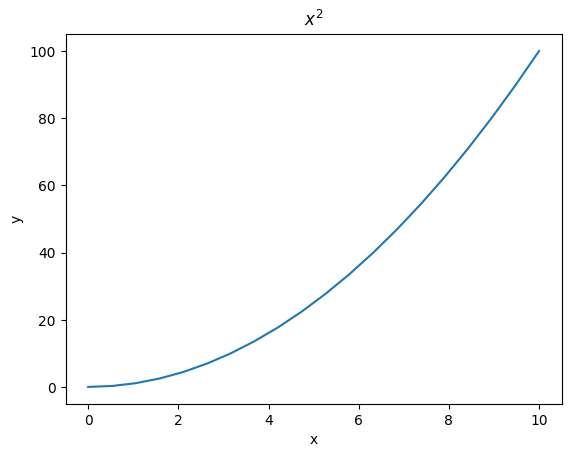

In [10]:
import numpy as np
x = np.linspace( 0, 10, 20 )
y = x**2
plt.plot( x, y ) 
plt.title('$x^2$')
plt.xlabel('x')
plt.ylabel('y')

# plt.savefig(os.path.join( img_path, 'line-plot_blue.png') )

#### Object oriented interface

Text(0, 0.5, 'y')

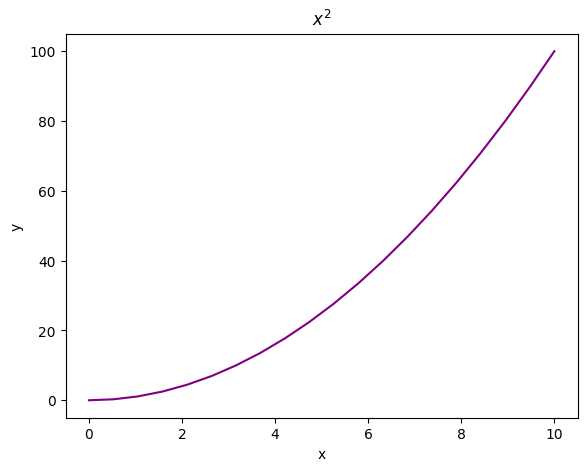

In [11]:
fig = plt.figure()
ax = fig.add_axes( [0.1,0.1,0.8,0.8] ) #left, bottom, width, and height 
ax.plot( x, x**2, 'purple' )
ax.set_title('$x^2$')
ax.set_xlabel('x')
ax.set_ylabel('y')

# fig.savefig(os.path.join( img_path, 'line-plot_1.png') )

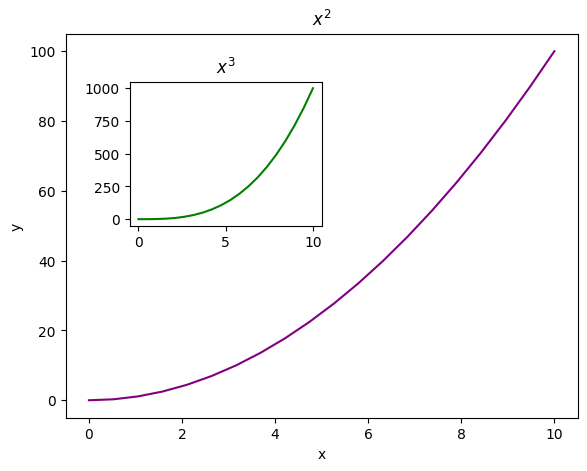

In [12]:
fig = plt.figure()
ax = fig.add_axes( [0.1,0.1,0.8,0.8] ) #left, bottom, width, and height 
ax.plot( x, x**2, 'purple' )
ax.set_title('$x^2$')
ax.set_xlabel('x')
ax.set_ylabel('y')

ax2 = fig.add_axes( [0.2,0.5,0.3,0.3] ) #left, bottom, width, and height 
ax2.set_title('$x^3$')
ax2.plot(x,x**3,'green')

# fig.savefig(os.path.join( img_path, 'line-plot_2.png') )

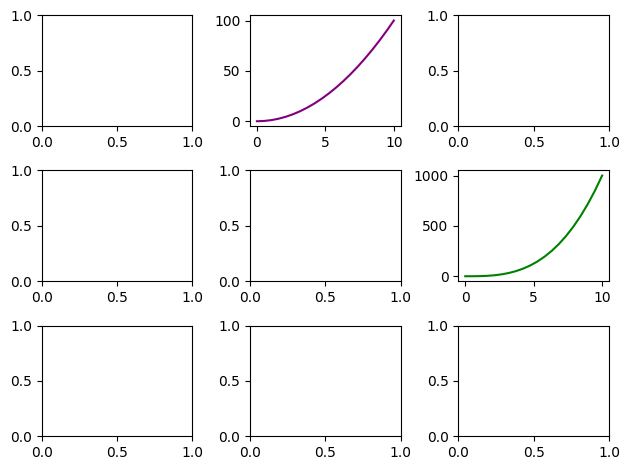

In [13]:
fig, axes = plt.subplots(nrows=3, ncols=3)
plt.tight_layout()

axes[0,1].plot(x,x**2,'purple')
axes[1,2].plot(x,x**3,'green')

# fig.savefig(os.path.join( img_path, 'subplots.png') )

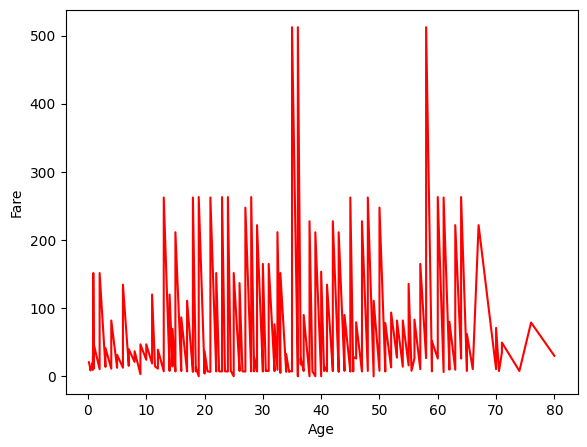

In [14]:
fare = [p['fare'] for p in passengers if p['fare']!= '' and p['age'] != '']
age = [p['age'] for p in passengers if p['fare']!= '' and p['age'] != '']
#print( len(fare), len(age) )
sage, sfare = (list(t) for t in zip(*sorted(zip(age, fare))))

fig = plt.figure()
ax = fig.add_axes( [0.1,0.1,0.8,0.8] ) #left, bottom, width, and height 
ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.plot( sage, sfare, 'red' )

# fig.savefig(os.path.join( img_path, 'line_age-fare.png') )

#### histograms

Text(0, 0.5, 'Frequency')

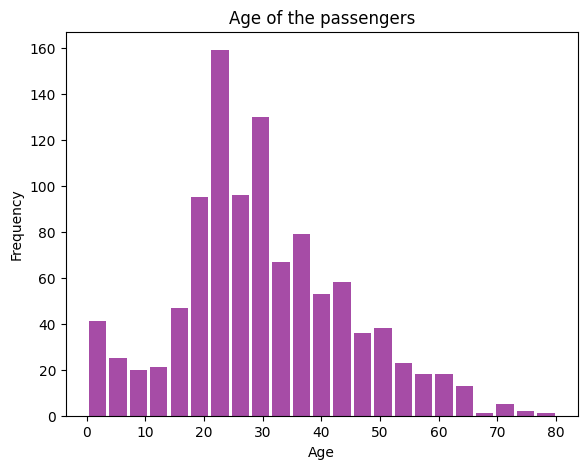

In [15]:
p_ages = [p['age'] for p in passengers if p['age']!='']

fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8])
n, bins, patches = ax.hist(x=p_ages, bins='auto', color='purple', alpha=0.7, rwidth=0.85)
ax.set_title('Age of the passengers')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')

# fig.savefig(os.path.join( img_path, 'histo_age.png') )


#plt.grid(axis='y', alpha=0.75)
#plt.xlabel('Age')
#plt.ylabel('Frequency')
#plt.title('Age of the Titanic passengers')
#plt.text(23, 45, r'$\mu=15, b=3$')
#maxfreq = n.max()
# Set a clean upper y-axis limit.
#plt.ylim(ymax=np.ceil(maxfreq / 10) * 10 if maxfreq % 10 else maxfreq + 10)

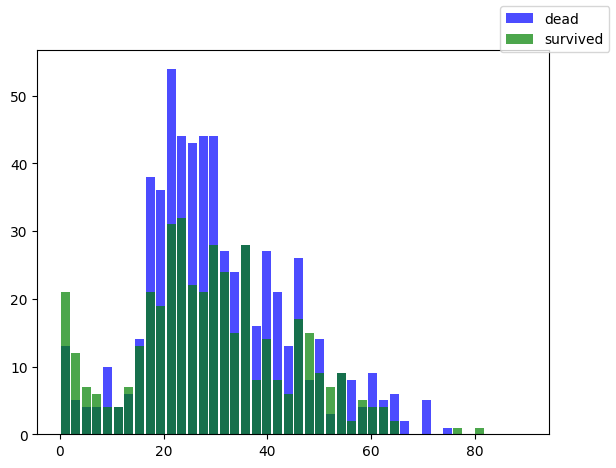

In [16]:
p_surv = [p['age'] for p in passengers if p['age']!='' and p['survived'] == 1]
p_dead = [p['age'] for p in passengers if p['age']!='' and p['survived'] == 0]

fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8])

bins = np.linspace(0, 90, 45)

n, _, patches = ax.hist(x=p_dead, bins=bins, color='blue', alpha=0.7, rwidth=0.85, label='dead')
n2, _, patches2 = ax.hist(x=p_surv, bins=bins, color='green', alpha=0.7, rwidth=0.85, label='survived')
fig.legend(loc='upper right')

# fig.savefig(os.path.join( img_path, 'histo_age-surv.png') )

/home/chloe/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/home/chloe/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


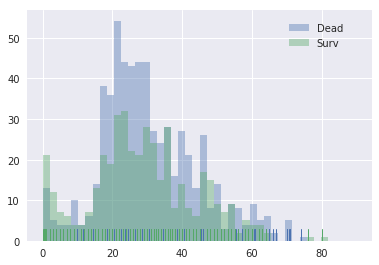

In [205]:
# TODO: try with Seaborn
# With seaborn
import seaborn as sns
sns.set()

p_surv = [p['age'] for p in passengers if p['age']!='' and p['survived'] == 1]
p_dead = [p['age'] for p in passengers if p['age']!='' and p['survived'] == 0]

fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8])

bins = np.linspace(0, 90, 45)

#rug plot: draws a small vertical tick at each observation
sns.distplot(p_dead, kde=False, rug=True, ax=ax, bins=bins, label="Dead")
sns.distplot(p_surv, kde=False, rug=True, ax=ax, bins=bins, label="Surv")
fig.legend(loc=[0.75,0.8])

fig.savefig(os.path.join( img_path, 'histo_age-surv_seaborn.png') )

/home/chloe/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
/home/chloe/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


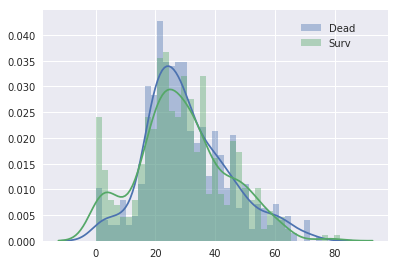

In [208]:
#kde: Kernel density estimation (density curve)
fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8])

bins = np.linspace(0, 90, 45)
sns.distplot(p_dead, kde=True, ax=ax, bins=bins, label="Dead")
sns.distplot(p_surv, kde=True, ax=ax, bins=bins, label="Surv")
fig.legend(loc=[0.75,0.8])


In [ ]:
# TODO: check survival wrt fare :/

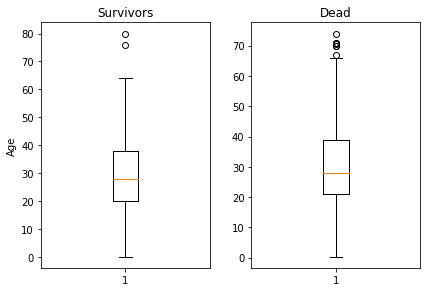

In [173]:
fig, axes = plt.subplots(ncols=2)
plt.tight_layout()

axes[0].boxplot(p_surv)
axes[0].set_title('Survivors')
axes[1].boxplot(p_dead)
axes[1].set_title('Dead')
axes[0].set_ylabel('Age')
fig.savefig(os.path.join( img_path, 'box_age-surv.png') )

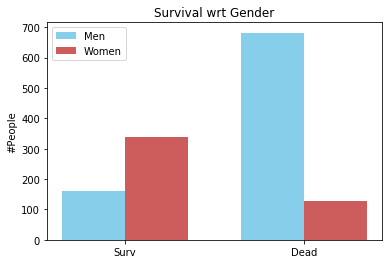

In [180]:
f_surv = len( [p for p in passengers if p['survived'] == 1 and p['sex']=='female'] )
f_dead = len( [p for p in passengers if p['survived'] == 0 and p['sex']=='female'] )
m_surv = len( [p for p in passengers if p['survived'] == 1 and p['sex']=='male'] )
m_dead = len( [p for p in passengers if p['survived'] == 0 and p['sex']=='male'] )

ind = np.arange(2)  # the x locations for the groups
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(ind - width/2, [m_surv, m_dead], width, color='SkyBlue', label='Men')
rects2 = ax.bar(ind + width/2, [f_surv, f_dead], width, color='IndianRed', label='Women')

ax.set_ylabel('#People')
ax.set_title('Survival wrt Gender')
ax.set_xticks(ind)
ax.set_xticklabels(('Surv', 'Dead'))
ax.legend()

fig.savefig(os.path.join( img_path, 'bar_sex-surv.png') )

#### Scatter plots

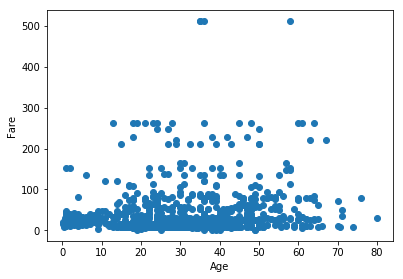

In [23]:
fare = [p['fare'] for p in passengers if p['fare']!= '' and p['age'] != '']
age = [p['age'] for p in passengers if p['fare']!= '' and p['age'] != '']
#print( len(fare), len(age) )
sage, sfare = (list(t) for t in zip(*sorted(zip(age, fare))))

fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8])
ax.scatter(age, fare)
ax.set_xlabel('Age')
ax.set_ylabel('Fare')

fig.savefig(os.path.join( img_path, 'scatter_age-fare.png') )

1308 1308


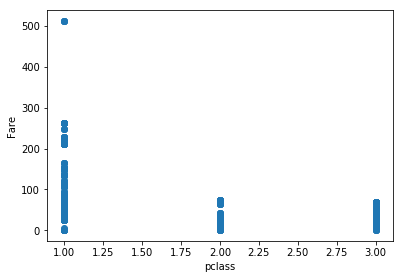

In [22]:
fare = [p['fare'] for p in passengers if p['fare']!= '' and p['pclass'] != '']
pclass = [p['pclass'] for p in passengers if p['fare']!= '' and p['pclass'] != '']
print( len(fare), len(pclass) )
spclass, sfare = (list(t) for t in zip(*sorted(zip(pclass, fare))))

fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8])
ax.scatter(pclass, fare)
ax.set_xlabel('pclass')
ax.set_ylabel('Fare')

fig.savefig(os.path.join( img_path, 'scatter_pclass-fare.png') )

In [ ]:
# TODO: try with Age and Fare

## Seaborn

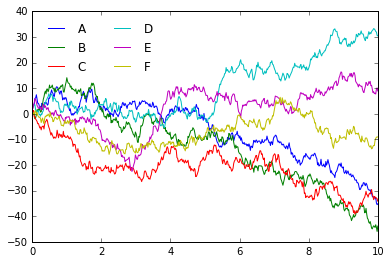

In [48]:
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline
import numpy as np

# Create some data
#rng = np.random.RandomState(0)
x = np.linspace(0, 10, 500)
y = np.cumsum(rng.randn(500, 6), 0)

# Plot the data with Matplotlib defaults
fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8])
ax.plot(x,y)
#loc: 2-tuple giving x, y of the lower-left corner of the legend in axes coordinates 
fig.legend('ABCDEF', ncol=2, loc=(0.1,0.7), framealpha=.5, frameon=False);

fig.savefig(os.path.join( img_path, 'matplotlib.png') )

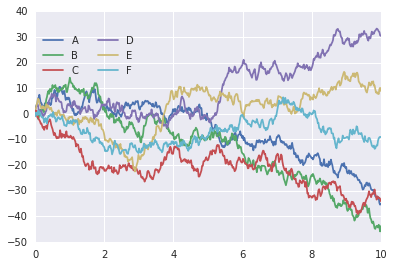

In [49]:
import seaborn as sns
sns.set()

# same plotting code as above!
fig = plt.figure()
ax = fig.add_axes([0.1,0.1,0.8,0.8])
ax.plot(x,y)
fig.legend('ABCDEF', ncol=2, loc=(0.1,0.7));
#plt.plot(x, y)
#plt.legend('ABCDEF', ncol=2, loc='upper left');

fig.savefig(os.path.join( img_path, 'seaborn.png') )

#### Pair plots

Using the Iris dataset (available in Seaborn, but also in Scikit)

In [85]:
import seaborn as sns
sns.set()

# Pandas DataFrame
iris = sns.load_dataset("iris")
iris.head()

# sns.get_dataset_names()
# availale datasets: ['anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 
# 'dots', 'exercise', 'flights', 'fmri', 'gammas', 'iris', 'mpg', 'planets', 'tips', 'titanic']

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


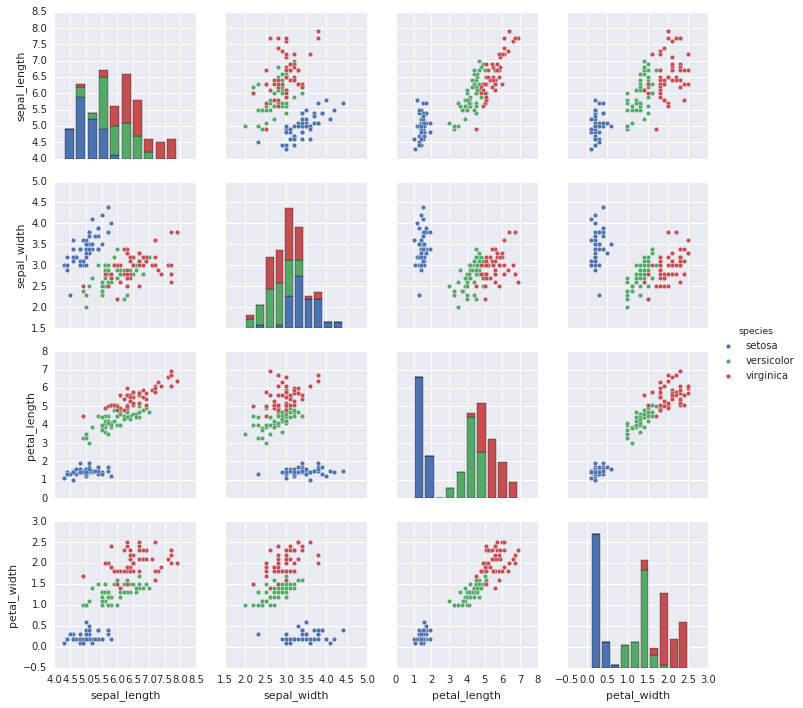

In [69]:
#  higher-level functions create a figure when called 
fig = sns.pairplot(iris, hue='species', size=2.5)

fig.savefig(os.path.join( img_path, 'pairplot_iris.png') )

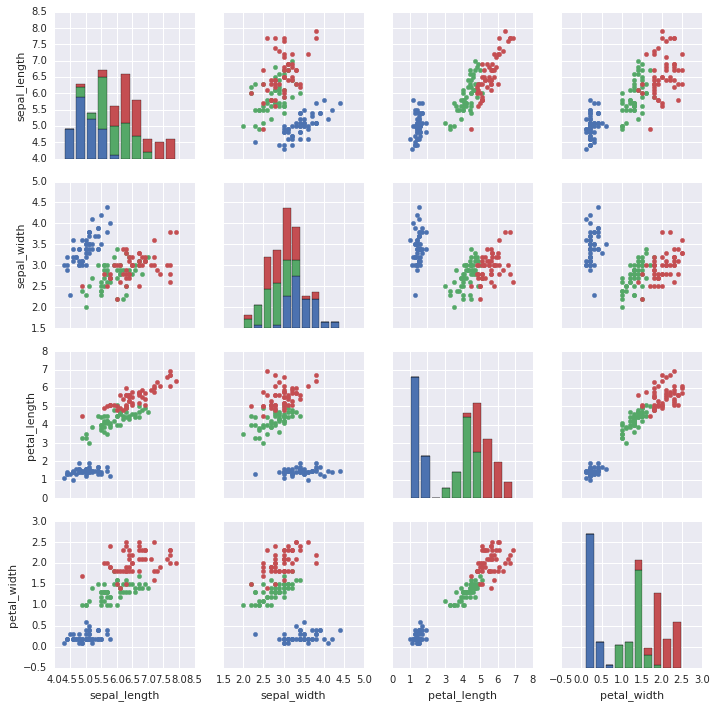

In [71]:
# Using PairGrid, more flexible
g = sns.PairGrid(iris, hue="species")
g.map_diag(plt.hist)
g.map_offdiag(plt.scatter);

In [86]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


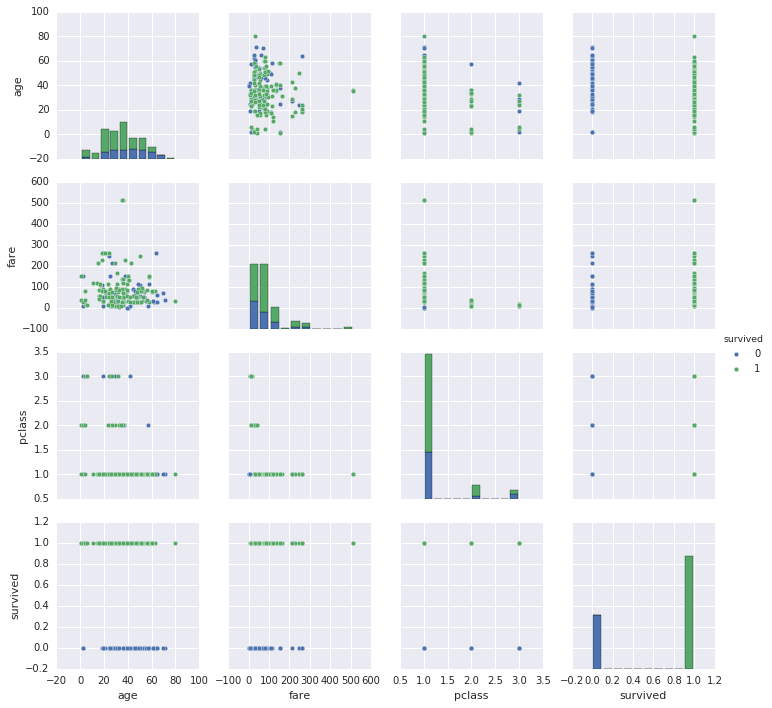

In [99]:
titanic = titanic.dropna()
fig = sns.pairplot(titanic[["age", "fare", "sex", "pclass","survived"]], hue="survived" )
fig.savefig(os.path.join( img_path, 'pairplot_titanic.png') )

## Visualising results



#### Heat maps

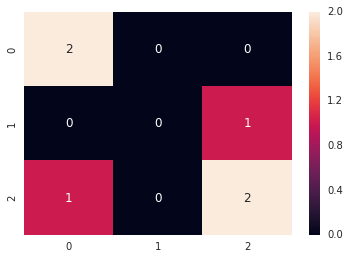

In [151]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
sns.set()

y_true = [2, 0, 2, 2, 0, 1]
y_pred = [0, 0, 2, 2, 0, 2]
cfn_matrix = confusion_matrix(y_true, y_pred)

df_cm = pd.DataFrame(cfn_matrix, index = [i for i in "012"], columns = [i for i in "012"])

fig = sns.heatmap(df_cm, annot=True, fmt='d')

fig.figure.savefig(os.path.join( img_path, 'heat_example.png') )

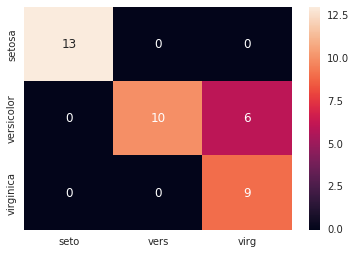

In [152]:
# Example from: https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html#sphx-glr-auto-examples-model-selection-plot-confusion-matrix-py
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names
# Split the data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
# Run classifier
classifier = svm.SVC(kernel='linear', C=0.01)
y_pred = classifier.fit(X_train, y_train).predict(X_test)

cfn_matrix = confusion_matrix(y_test, y_pred)

df_cm = pd.DataFrame(cfn_matrix, index = class_names, columns = [c[:4] for c in class_names])

fig = sns.heatmap(df_cm, annot=True, fmt='d')

fig.figure.savefig(os.path.join( img_path, 'heat_iris.png') )

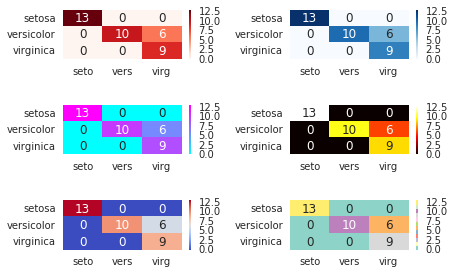

In [153]:
fig, axes = plt.subplots(nrows=3,ncols=2)
plt.tight_layout(w_pad=4, h_pad=2.0)
# Use colormap from Matplotlib: https://matplotlib.org/examples/color/colormaps_reference.html
cmap=plt.cm.Reds
# Sequential are better
sns.heatmap(df_cm, annot=True, fmt='d', cmap=cmap, ax=axes[0,0])
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1])
sns.heatmap(df_cm, annot=True, fmt='d', cmap='cool', ax=axes[1,0])
sns.heatmap(df_cm, annot=True, fmt='d', cmap='hot', ax=axes[1,1])
sns.heatmap(df_cm, annot=True, fmt='d', cmap='coolwarm', ax=axes[2,0]) # or diverging
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Set3', ax=axes[2,1]) # Not qualitative

fig.savefig(os.path.join( img_path, 'heat_cmap.png') )

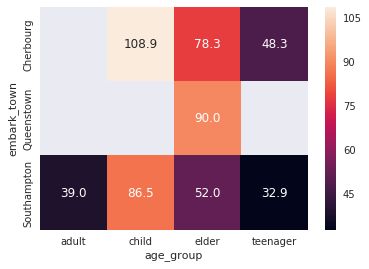

In [109]:
import pandas as pd
bins = [0, 12, 17, 60, np.inf]
labels = ['child', 'teenager', 'adult', 'elder']
age_groups = pd.cut(titanic.age, bins, labels=labels)
titanic['age_group'] = age_groups

df = titanic.pivot_table(index='embark_town', columns='age_group', values='fare', aggfunc=np.median)
sns.heatmap(df, annot=True, fmt=".1f")